# Компартменты и saddle plots для Hi-C матриц

В этом блокноте мы разберём анализ **A/B-компартментов** на Hi-C данных.

Три основные вещи:

1. eigenvector `E1`, который часто отражает A/B-компартменты
2. Визуализация `E1` рядом с Hi-C матрицей
3. **saddle plot**, который показывает силу компартментализации

Интерпритация: участки одного типа чаще контактируют друг с другом. Активные A-компартменты чаще контактируют с A-компартментами, менее активные B-компартменты — с B-компартментами


In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import cooler
import cooltools
import bioframe

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable

plt.rcParams['figure.figsize'] = (8, 6)


## 1. Загрузка данных

Для компартментов часто используют разрешение от 100 kb до 1 Mb


In [2]:
resolution = 100_000

sample_names = ['MoPh7_enr_v2', 'MoPh11_enr_v2', 'MoPh14_enr_v2', 'MoPh15_enr_v2']

cool_paths = {
    sample: f'../data/{sample}.mcool::/resolutions/{resolution}'
    for sample in sample_names
}

clrs = {
    sample: cooler.Cooler(path)
    for sample, path in cool_paths.items()
}


## 2. Проверяем балансировку

Для анализа компартментов нужна сбалансированная матрица. Веса балансировки лежат в колонке `weight` таблицы `bins`.


In [3]:
for sample, clr in clrs.items():
    if 'weight' in clr.bins().columns:
        print(f'{sample}: weight column found')
    else:
        print(f'{sample}: no weight column found. Run cooler balance first.')


MoPh7_enr_v2: weight column found
MoPh11_enr_v2: weight column found
MoPh14_enr_v2: weight column found
MoPh15_enr_v2: weight column found


## 3. Создаём view по хромосомам


In [4]:
# Берём первый образец как референс для списка хромосом, оставляем только каноничные хромосомы для анализа
example_clr = clrs['MoPh7_enr_v2']

canonical_chroms = [str(i) for i in range(1, 23)] + ['X', 'Y']

chromsizes = example_clr.chromsizes.reset_index()
chromsizes.columns = ['chrom', 'length']

chromsizes = chromsizes[
    chromsizes['chrom'].isin(canonical_chroms)
].copy()

view_df = pd.DataFrame({
    'chrom': chromsizes['chrom'],
    'start': 0,
    'end': chromsizes['length'],
    'name': chromsizes['chrom']
})

view_df.head()


,chrom,start,end,name
0,1,0,248387328,1
1,2,0,242696752,2
2,3,0,201105948,3
3,4,0,193574945,4
4,5,0,182045439,5


## 4. Phasing track

Eigenvector можно умножить на `-1`, и математически он останется тем же самым решением.  
Поэтому направление E1 нужно зафиксировать.

В Hi-C анализе часто используют **GC content** как phasing track:

- E1 положительно коррелирует с GC-rich участками
- GC-rich участки часто соответствуют A-компартменту
- GC-poor участки часто соответствуют B-компартменту

Но для этого нужен FASTA-файл генома.  
Чтобы блокнот запускался без дополнительных больших файлов, ниже мы делаем два варианта:

1. Если файл `gc_track.tsv` есть — используем его для ориентации E1.
2. Если файла нет — считаем E1 без phasing track и помним, что знак E1 может быть произвольным.


In [5]:
# Этот блок нужен только если есть FASTA-файл генома.
# Если FASTA нет, блокнот спокойно пойдёт дальше без GC phasing track.
fasta_path = '../../day1/data/reference/T2T_human.fna'
out_path = f'../data/gc_track_res{resolution}.tsv'

if os.path.exists(fasta_path):
    bins = example_clr.bins()[:][['chrom', 'start', 'end']].copy()
    bins = bins[bins['chrom'].isin(canonical_chroms)].copy()

    fasta_records = bioframe.load_fasta(fasta_path)
    fasta_records = {
        chrom.replace('chr', '', 1): seq
        for chrom, seq in fasta_records.items()
    }

    gc_track = bioframe.frac_gc(
        bins,
        fasta_records,
        mapped_only=True,
        return_input=True
    )

    gc_track = gc_track[['chrom', 'start', 'end', 'GC']].copy()
    gc_track.to_csv(out_path, sep='	', index=False)
    print(f'GC track saved to {out_path}')
else:
    print(f'No FASTA file found: {fasta_path}')
    print('Skip GC track creation.')


GC track saved to ../data/gc_track_res100000.tsv


In [6]:
gc_track_path = f'../data/gc_track_res{resolution}.tsv'
if os.path.exists(gc_track_path):
    phasing_track = pd.read_csv(gc_track_path, sep='\t')
    print('GC phasing track loaded:')
    display(phasing_track.head())
else:
    phasing_track = None
    print('No GC phasing track found.')
    print('E1 will be calculated without fixed orientation.')

GC phasing track loaded:


,chrom,start,end,GC
0,1,0,100000,0.45450
1,1,100000,200000,0.42602
2,1,200000,300000,0.43919
3,1,300000,400000,0.57469
4,1,400000,500000,0.62509


## 5. Считаем E1 для одного образца

Для рассчета собственного вектора используем `cooltools.eigs_cis`

Результат состоит из двух таблиц:

- eigenvalues — собственные значения вектора
- eigvecs — eigenvectors, включая `E1`, `E2`, `E3`


In [7]:
sample = 'MoPh7_enr_v2'
clr = clrs[sample]

cis_eigs = cooltools.eigs_cis(
    clr,
    phasing_track,
    view_df=view_df,
    n_eigs=3,
    clr_weight_name='weight',
    ignore_diags=3
)

eigenvalues = cis_eigs[0]
eigvecs = cis_eigs[1]

display(eigenvalues)
display(eigvecs.head())


,chrom,start,end,name,eigval1,eigval2,eigval3
0,1,0,248387328,1,674.426771,453.982422,-391.776823
1,2,0,242696752,2,915.280327,510.260213,433.995376
2,3,0,201105948,3,756.605589,501.579799,-410.363400
3,4,0,193574945,4,704.731085,636.207963,-628.284409
4,5,0,182045439,5,619.747466,406.230018,356.211379
5,6,0,172126628,6,598.511711,346.828943,-332.830944
6,7,0,160567428,7,521.308197,346.956059,279.430402
7,8,0,146259331,8,510.852929,341.718037,-293.791753
8,9,0,150617247,9,428.174562,304.578145,-265.421484
9,10,0,134758134,10,526.420663,308.437744,241.974824


,chrom,start,end,KR,VC,VC_SQRT,weight,E1,E2,E3
0,1,0,100000,0.049157,0.012325,0.048936,NaN,NaN,NaN,NaN
1,1,100000,200000,0.046352,0.013865,0.051904,NaN,NaN,NaN,NaN
2,1,200000,300000,0.421168,1.050692,0.451831,NaN,NaN,NaN,NaN
3,1,300000,400000,0.732517,2.820845,0.740334,0.042644,0.296658,0.007291,0.195547
4,1,400000,500000,0.830830,3.501792,0.824866,0.034806,0.655042,-0.142760,0.744945


## 6. Делаем eigenvector track

Для дальнейших шагов нам нужен bedGraph-like track с колонками:

- `chrom`
- `start`
- `end`
- `E1`

`E1` — это первый eigenvector. Именно его чаще всего используют как приближение A/B-компартментов.


In [8]:
eigenvector_track = eigvecs[['chrom', 'start', 'end', 'E1']].copy()

eigenvector_track['compartment'] = np.where(
    eigenvector_track['E1'] >= 0,
    'A-like',
    'B-like'
)

eigenvector_track.head()


,chrom,start,end,E1,compartment
0,1,0,100000,NaN,B-like
1,1,100000,200000,NaN,B-like
2,1,200000,300000,NaN,B-like
3,1,300000,400000,0.296658,A-like
4,1,400000,500000,0.655042,A-like


## 6.1. Histogram E1

Посмотрим распределение значений `E1`. Это помогает понять, где находятся два полюса компартментализации.

Если E1 ориентирован по GC-track, то обычно:

- `E1 < 0` — B-like, более GC-poor участки;
- `E1 > 0` — A-like, более GC-rich участки.

В saddle plot это соответствует углам:

- low E1 × low E1 — BB;
- high E1 × high E1 — AA.

Если GC-track не использовался, знак E1 может быть перевёрнут, но разделение на два типа компартментов всё равно сохраняется.


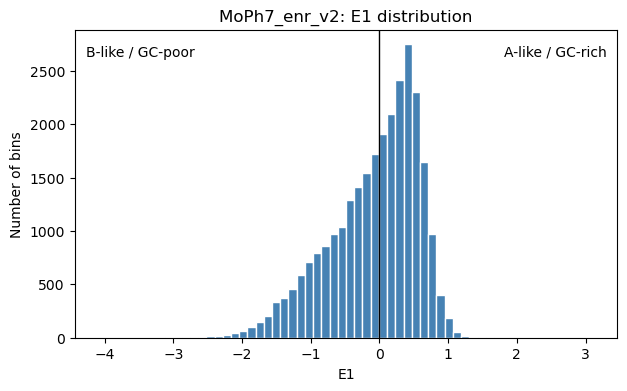

In [9]:
e1_values = eigenvector_track['E1'].dropna()

fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(
    e1_values,
    bins=60,
    color='steelblue',
    edgecolor='white'
)

ax.axvline(0, color='black', linewidth=1)

if phasing_track is not None:
    left_label = 'B-like / GC-poor'
    right_label = 'A-like / GC-rich'
else:
    left_label = 'low E1'
    right_label = 'high E1'

ax.text(
    0.02, 0.95, left_label,
    transform=ax.transAxes,
    ha='left', va='top'
)
ax.text(
    0.98, 0.95, right_label,
    transform=ax.transAxes,
    ha='right', va='top'
)

ax.set(
    xlabel='E1',
    ylabel='Number of bins',
    title=f'{sample}: E1 distribution'
)

plt.show()


## 7. Визуализируем E1 вдоль одной хромосомы

Положительные и отрицательные значения E1 можно интерпретировать как два типа компартментов.

Важно: если мы не использовали phasing track, то знак может быть перевёрнут.  
То есть `E1 > 0` и `E1 < 0` всё равно разделяют два типа компартментов, но нельзя автоматически сказать, где A, а где B.


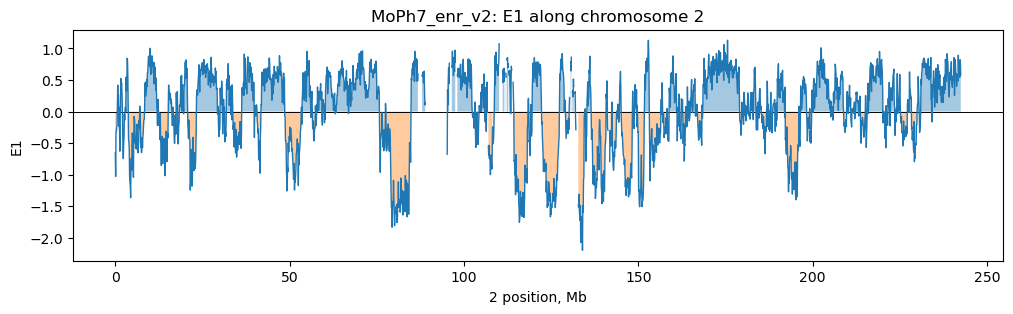

In [10]:
chrom = '2'

if chrom not in clr.chromnames:
    chrom = clr.chromnames[0]

e1_chrom = eigenvector_track[eigenvector_track['chrom'] == chrom].copy()

fig, ax = plt.subplots(figsize=(12, 3))

ax.axhline(0, color='black', linewidth=0.7)
ax.plot(
    e1_chrom['start'] / 1_000_000,
    e1_chrom['E1'],
    linewidth=1
)

ax.fill_between(
    e1_chrom['start'] / 1_000_000,
    0,
    e1_chrom['E1'],
    where=e1_chrom['E1'] >= 0,
    alpha=0.4
)

ax.fill_between(
    e1_chrom['start'] / 1_000_000,
    0,
    e1_chrom['E1'],
    where=e1_chrom['E1'] < 0,
    alpha=0.4
)

ax.set(
    xlabel=f'{chrom} position, Mb',
    ylabel='E1',
    title=f'{sample}: E1 along chromosome {chrom}'
)

plt.show()


## 8. Hi-C матрица и E1 рядом

Теперь посмотрим, как E1 связан с plaid-pattern на Hi-C карте.

Plaid-pattern — это шахматный рисунок на матрице, который возникает из-за того, что участки одного компартментного типа чаще контактируют друг с другом.


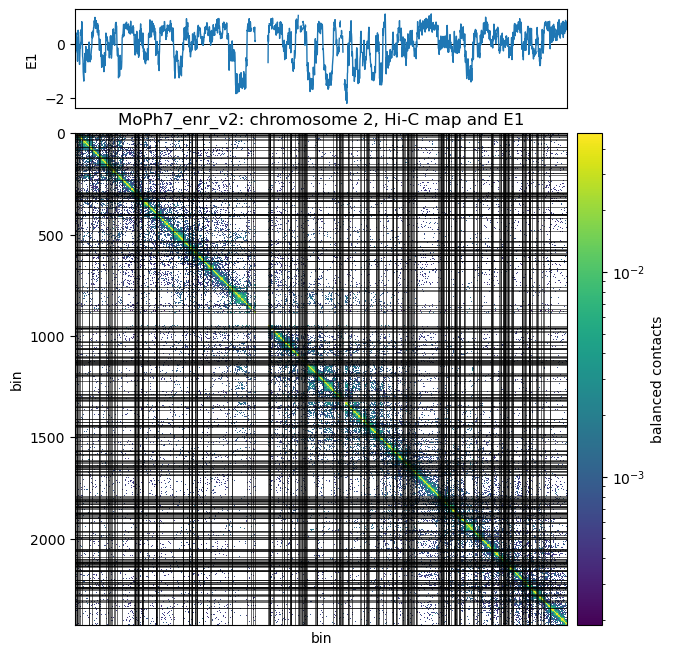

In [11]:
region = chrom
matrix = clr.matrix(balance=True).fetch(region)

e1_region = eigenvector_track[eigenvector_track['chrom'] == region].copy()
e1_region = e1_region.iloc[:matrix.shape[0]]

fig, ax = plt.subplots(figsize=(8, 8))

positive_values = matrix[np.isfinite(matrix) & (matrix > 0)]
vmax = np.nanpercentile(positive_values, 99) if len(positive_values) > 0 else 1

im = ax.matshow(
    matrix,
    norm=LogNorm(vmax=vmax),
)

divider = make_axes_locatable(ax)

cax = divider.append_axes('right', size='5%', pad=0.1)
plt.colorbar(im, cax=cax, label='balanced contacts')

ax_e1 = divider.append_axes('top', size='20%', pad=0.25, sharex=ax)
ax_e1.axhline(0, color='black', linewidth=0.7)
ax_e1.plot(e1_region['E1'].values, linewidth=1)
ax_e1.set_ylabel('E1')
ax_e1.set_xticks([])

# Показываем границы между положительным и отрицательным E1
e1_sign = (e1_region['E1'] > 0).astype(int).values
boundaries = np.where(np.diff(e1_sign))[0]

for b in boundaries:
    ax.axhline(b, color='black', linewidth=0.4)
    ax.axvline(b, color='black', linewidth=0.4)

ax.set_title(f'{sample}: chromosome {region}, Hi-C map and E1')
ax.set_xlabel('bin')
ax.set_ylabel('bin')

plt.show()


## 9. Считаем expected cis

Для saddle plot нужно нормировать контакты на ожидаемую частоту контактов при данном расстоянии.

Это нужно потому, что близкие участки генома почти всегда контактируют чаще, чем далёкие.  
`expected_cis` считает эту зависимость contact frequency от расстояния.


In [12]:
expected = cooltools.expected_cis(
    clr=clr,
    view_df=view_df,
    clr_weight_name='weight',
    ignore_diags=2,
    nproc=4
)

expected.head()


INFO:root:creating a Pool of 4 workers


,region1,region2,dist,dist_bp,contact_frequency,n_total,n_valid,count.sum,balanced.sum,count.avg,balanced.avg,balanced.avg.smoothed,balanced.avg.smoothed.agg
0,1,1,0,0,NaN,2484,2140,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1,1,100000,0.000408,2483,2116,NaN,NaN,NaN,NaN,0.000413,0.000408
2,1,1,2,200000,0.035872,2482,2101,173517.0,81.996296,69.910153,0.039027,0.036343,0.035872
3,1,1,3,300000,0.025518,2481,2092,116265.0,55.241252,46.862152,0.026406,0.025394,0.025518
4,1,1,4,400000,0.018992,2480,2084,83541.0,40.013637,33.685887,0.019200,0.018492,0.018992


## 10. Параметры saddle plot

Saddle plot группирует бины по значениям E1.

Например:

- самые низкие значения E1 — один край
- самые высокие значения E1 — другой край
- промежуточные значения — группы между ними

Обычно крайние выбросы исключают. Здесь мы используем диапазон от 2.5% до 97.5%.


In [13]:
Q_LO = 0.025
Q_HI = 0.975
N_GROUPS = 38

print('qrange:', Q_LO, Q_HI)
print('number of groups:', N_GROUPS)


qrange: 0.025 0.975
number of groups: 38


## 11. Считаем saddle matrix

`cooltools.saddle` возвращает две матрицы:

- `interaction_sum` — сумма observed/expected контактов для каждой пары групп
- `interaction_count` — сколько пикселей вошло в каждую пару групп

Обычно визуализируют отношение:

`interaction_sum / interaction_count`


In [14]:
interaction_sum, interaction_count = cooltools.saddle(
    clr,
    expected,
    eigenvector_track[['chrom', 'start', 'end', 'E1']],
    contact_type='cis',
    n_bins=N_GROUPS,
    qrange=(Q_LO, Q_HI),
    view_df=view_df,
    clr_weight_name='weight'
)

saddle_matrix = interaction_sum / interaction_count

print('saddle matrix shape:', saddle_matrix.shape)


saddle matrix shape: (40, 40)


## 12. Простая визуализация saddle plot

В saddle plot:

- верхний левый угол — контакты между бинaми с низким E1
- нижний правый угол — контакты между бинaми с высоким E1
- противоположные углы — контакты между разными типами компартментов

Если компартментализация сильная, то одинаковые типы компартментов будут обогащены контактами.


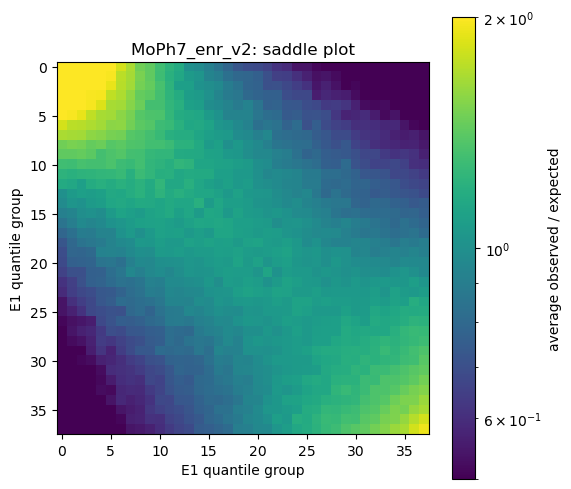

In [15]:
# У saddle matrix есть дополнительные строки и колонки для outlier-групп.
# Для простой визуализации убираем их.
saddle_core = saddle_matrix[1:-1, 1:-1]

fig, ax = plt.subplots(figsize=(6, 6))

im = ax.imshow(
    saddle_core,
    origin='upper',
    norm=LogNorm(vmin=0.5, vmax=2)
)

ax.set(
    xlabel='E1 quantile group',
    ylabel='E1 quantile group',
    title=f'{sample}: saddle plot'
)

plt.colorbar(im, ax=ax, label='average observed / expected')

plt.show()


## 14. Повторяем анализ для всех образцов

Теперь посчитаем E1, saddle matrix и saddle strength для всех четырёх карт.

Для простоты будем использовать один и тот же `view_df`.


In [16]:
from cooltools.api.saddle import saddle_strength
results = {}

for sample, clr in clrs.items():
    print(f'Processing {sample}...')

    if 'weight' not in clr.bins().columns:
        print(f'  Skipping {sample}: no weight column')
        continue

    cis_eigs = cooltools.eigs_cis(
        clr,
        phasing_track=phasing_track,
        view_df=view_df,
        n_eigs=3,
        clr_weight_name='weight',
        ignore_diags=3
    )

    eigvecs = cis_eigs[1]
    eigenvector_track = eigvecs[['chrom', 'start', 'end', 'E1']].copy()

    expected = cooltools.expected_cis(
        clr=clr,
        view_df=view_df,
        clr_weight_name='weight',
        ignore_diags=2,
        nproc=4
    )

    interaction_sum, interaction_count = cooltools.saddle(
        clr,
        expected,
        eigenvector_track,
        contact_type='cis',
        n_bins=N_GROUPS,
        qrange=(Q_LO, Q_HI),
        view_df=view_df,
        clr_weight_name='weight'
    )

    strength = saddle_strength(interaction_sum, interaction_count)

    results[sample] = {
        'eigvecs': eigvecs,
        'eigenvector_track': eigenvector_track,
        'expected': expected,
        'interaction_sum': interaction_sum,
        'interaction_count': interaction_count,
        'saddle_matrix': interaction_sum / interaction_count,
        'saddle_strength': strength
    }

print('Done.')


Processing MoPh7_enr_v2...


INFO:root:creating a Pool of 4 workers


Processing MoPh11_enr_v2...


INFO:root:creating a Pool of 4 workers


Processing MoPh14_enr_v2...


INFO:root:creating a Pool of 4 workers


Processing MoPh15_enr_v2...


INFO:root:creating a Pool of 4 workers


Done.


## 15. Сохраняем E1 как genome browser track

Сохраним трек компартментов для всех хромосом в двух форматах:

- `bedGraph` — простой текстовый формат;
- `bigWig` — бинарный формат для genome browser.


In [17]:
import pyBigWig
from pathlib import Path

out_dir = Path('../results/compartments')
out_dir.mkdir(parents=True, exist_ok=True)

chrom_order = {chrom: i for i, chrom in enumerate(canonical_chroms)}
chromsizes_for_bw = [
    (row['chrom'], int(row['length']))
    for _, row in chromsizes.iterrows()
]

for sample, data in results.items():
    track = data['eigenvector_track'][['chrom', 'start', 'end', 'E1']].copy()
    track = track[track['chrom'].isin(canonical_chroms)].copy()
    track = track.dropna(subset=['E1'])

    track['start'] = track['start'].astype(int)
    track['end'] = track['end'].astype(int)
    track['E1'] = track['E1'].astype(float)
    track['chrom_order'] = track['chrom'].map(chrom_order)
    track = track.sort_values(['chrom_order', 'start'])

    bedgraph_path = out_dir / f'{sample}_E1_res{resolution}.bedGraph'
    bw_path = out_dir / f'{sample}_E1_res{resolution}.bw'

    track[['chrom', 'start', 'end', 'E1']].to_csv(
        bedgraph_path,
        sep='	',
        header=False,
        index=False
    )

    bw = pyBigWig.open(str(bw_path), 'w')
    bw.addHeader(chromsizes_for_bw)

    for chrom, chrom_track in track.groupby('chrom', sort=False):
        bw.addEntries(
            chrom_track['chrom'].tolist(),
            chrom_track['start'].tolist(),
            ends=chrom_track['end'].tolist(),
            values=chrom_track['E1'].tolist()
        )

    bw.close()

    print(f'{sample}:')
    print(f'  {bedgraph_path}')
    print(f'  {bw_path}')


MoPh7_enr_v2:
  ../results/compartments/MoPh7_enr_v2_E1_res100000.bedGraph
  ../results/compartments/MoPh7_enr_v2_E1_res100000.bw
MoPh11_enr_v2:
  ../results/compartments/MoPh11_enr_v2_E1_res100000.bedGraph
  ../results/compartments/MoPh11_enr_v2_E1_res100000.bw
MoPh14_enr_v2:
  ../results/compartments/MoPh14_enr_v2_E1_res100000.bedGraph
  ../results/compartments/MoPh14_enr_v2_E1_res100000.bw
MoPh15_enr_v2:
  ../results/compartments/MoPh15_enr_v2_E1_res100000.bedGraph
  ../results/compartments/MoPh15_enr_v2_E1_res100000.bw


## 16. Сравниваем E1 между образцами

Сравним E1 вдоль одной хромосомы.

Важно: если E1 считался без phasing track, знак E1 может быть произвольным в каждом образце.  
Поэтому при сравнении иногда нужно вручную перевернуть знак одного из образцов, если видно, что профили зеркальные.


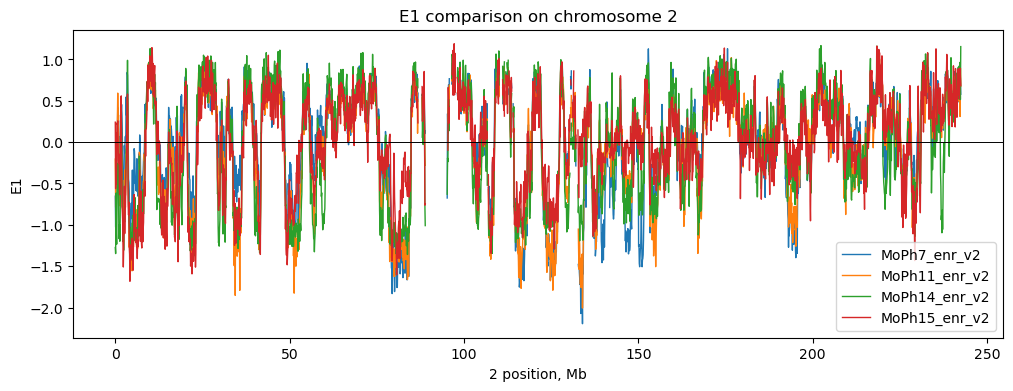

In [18]:
chrom = '2'

if chrom not in example_clr.chromnames:
    chrom = example_clr.chromnames[0]

fig, ax = plt.subplots(figsize=(12, 4))

for sample in sample_names:
    if sample not in results:
        continue

    e1 = results[sample]['eigenvector_track']
    e1_chrom = e1[e1['chrom'] == chrom].copy()

    ax.plot(
        e1_chrom['start'] / 1_000_000,
        e1_chrom['E1'],
        linewidth=1,
        label=sample
    )

ax.axhline(0, color='black', linewidth=0.7)

ax.set(
    xlabel=f'{chrom} position, Mb',
    ylabel='E1',
    title=f'E1 comparison on chromosome {chrom}'
)

ax.legend()
plt.show()


## 17. Сравниваем saddle plots

Построим saddle plot для каждого образца.

Так можно визуально сравнить силу компартментализации между условиями


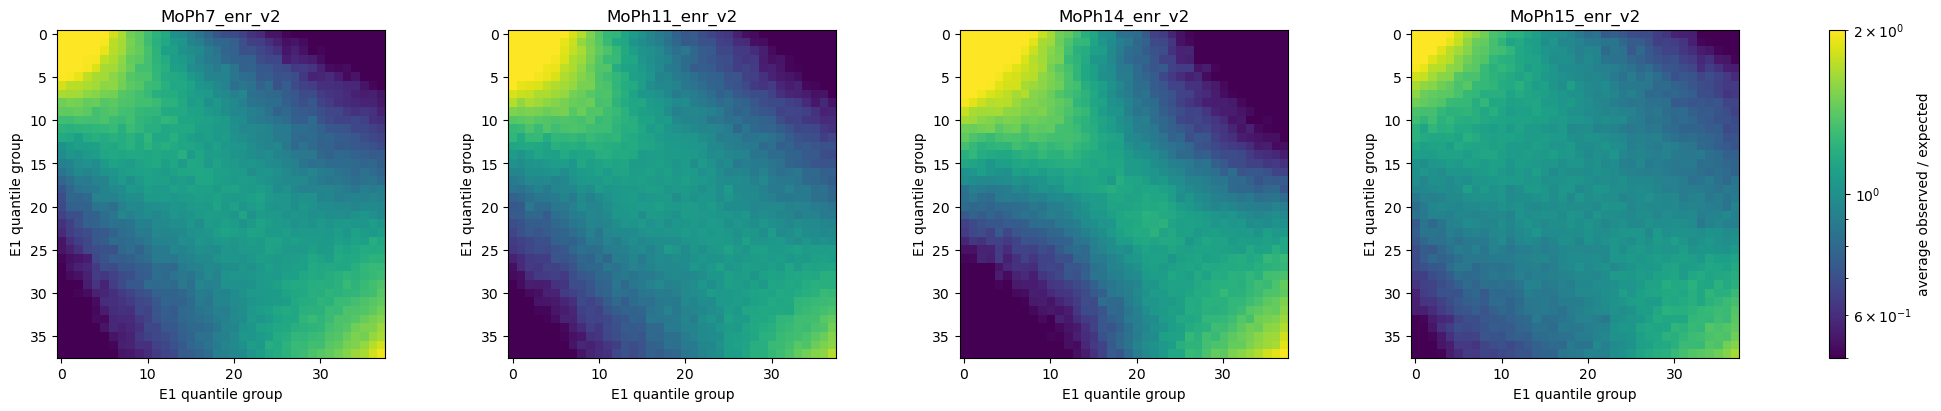

In [19]:
n_samples = len(results)

fig, axes = plt.subplots(
    1,
    n_samples,
    figsize=(5 * n_samples, 4),
    constrained_layout=True
)

if n_samples == 1:
    axes = [axes]

for ax, sample in zip(axes, results.keys()):
    saddle_core = results[sample]['saddle_matrix'][1:-1, 1:-1]

    im = ax.imshow(
        saddle_core,
        origin='upper',
        norm=LogNorm(vmin=0.5, vmax=2)
    )

    ax.set_title(sample)
    ax.set_xlabel('E1 quantile group')
    ax.set_ylabel('E1 quantile group')

fig.colorbar(im, ax=axes, label='average observed / expected')

plt.show()
